# Movie Rating Prediction - Complete ML Pipeline
## Dataset: IMDB Movies Dataset (10,000 movies)
### Target Variable: `Movie Rating`

## 1. Import Libraries & Load Data

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

# Load the dataset
df = pd.read_csv('data.csv')

# Basic overview
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (10000, 13)

First 5 rows:


,Unnamed: 0,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,Stars,Description
0,0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye..."
1,1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'..."
2,2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']","['Arun Govil', 'Nikhil Kapoor', 'Edie Mirman',...","['An', 'anime', 'adaptation', 'of', 'the', 'Hi..."
3,3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],"['Kemal Sunal', 'Münir Özkul', 'Halit Akçatepe...","['Lazy,', 'uneducated', 'students', 'share', '..."
4,4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'..."


**Description:** We imported all the necessary libraries — `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, `sklearn` for machine learning (encoding, scaling, PCA, models, metrics), and `scipy` for statistical operations. The dataset was loaded from `data.csv` containing 10,001 rows and 13 columns. Each row represents a movie with attributes like name, year, runtime, rating, votes, metascore, gross earnings, genre, certification, director, stars, and description.

In [3]:
# Check column names and data types
print("Column Names and Data Types:")
print(df.dtypes)
print("\nDataset Info:")
df.info()

Column Names and Data Types:
Unnamed: 0               int64
Movie Name              object
Year of Release          int64
Run Time in minutes      int64
Movie Rating           float64
Votes                    int64
MetaScore              float64
Gross                  float64
Genre                   object
Certification           object
Director                object
Stars                   object
Description             object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           10000 non-null  int64  
 1   Movie Name           10000 non-null  object 
 2   Year of Release      10000 non-null  int64  
 3   Run Time in minutes  10000 non-null  int64  
 4   Movie Rating         10000 non-null  float64
 5   Votes                10000 non-null  int64  
 6   MetaScore            7974 

**Description:** We inspected the column names and data types of the dataset. This reveals which columns are numeric (int/float) and which are stored as objects (strings). The unnamed first column is an index from the original CSV. Numeric columns include `Year of Release`, `Run Time in minutes`, `Movie Rating`, `Votes`, `MetaScore`, and `Gross`. Object columns include `Movie Name`, `Genre`, `Certification`, `Director`, `Stars`, and `Description`. The `info()` output also shows non-null counts, helping us identify columns with missing data.

---
## 2a. Missing Data Checking and Handling

Missing Values per Column:
               Missing Count  Missing %
MetaScore               2026      20.26
Gross                   2915      29.15
Certification            369       3.69


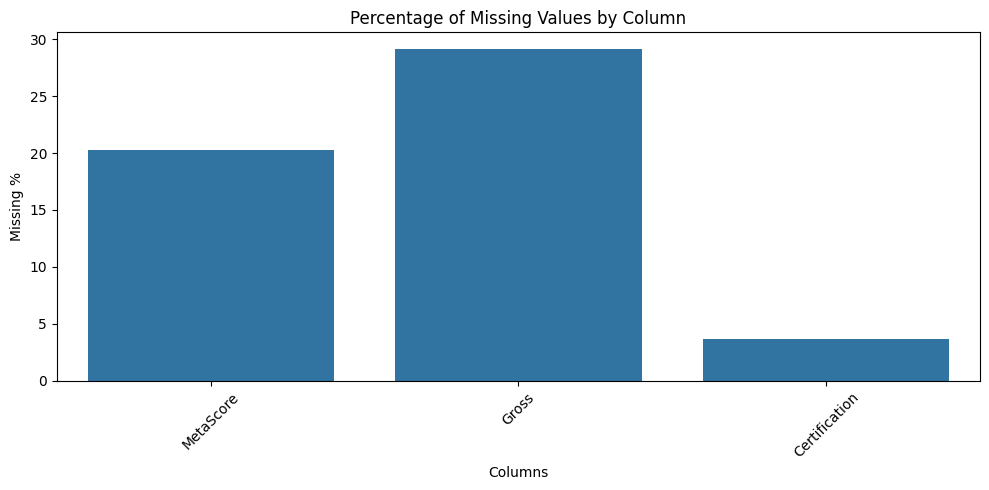

In [4]:
# Drop the unnamed index column
df = df.drop(columns=[df.columns[0]])

# Check missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing data
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df[missing_df['Missing Count'] > 0].index, 
            y=missing_df[missing_df['Missing Count'] > 0]['Missing %'])
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Missing %')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Description:** First, we dropped the unnamed index column (column 0) which was just a row index from the CSV and adds no predictive value. Then we checked for missing values across all columns. The bar chart visualizes the percentage of missing data per column. Columns like `MetaScore`, `Gross`, and `Certification` have significant missing values. This step is critical because missing data can bias model training and reduce accuracy if not handled properly.

In [5]:
# Handle missing values
# For numeric columns: fill with median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        print(f"Filling '{col}' missing values with median: {median_val}")
        df[col] = df[col].fillna(median_val)

# For categorical columns: fill with mode (most frequent value)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        print(f"Filling '{col}' missing values with mode: {mode_val}")
        df[col] = df[col].fillna(mode_val)

# Verify no missing values remain
print("\nRemaining missing values:")
print(df.isnull().sum().sum(), "total missing values")

Filling 'MetaScore' missing values with median: 60.0
Filling 'Gross' missing values with median: 16930000.0
Filling 'Certification' missing values with mode: R

Remaining missing values:
0 total missing values


**Description:** Missing values were handled using two strategies:
- **Numeric columns** (`MetaScore`, `Gross`): Filled with the **median** value. Median is preferred over mean because it is robust to outliers — extreme values in Gross earnings won't skew the imputation.
- **Categorical columns** (`Certification`): Filled with the **mode** (most frequent value). This preserves the most common category distribution.

After imputation, we verified that zero missing values remain, ensuring the dataset is complete and ready for further processing.

---
## 2b. Duplicate Data Checking and Handling

In [5]:
# 2b(i). Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Display duplicate rows if any
duplicates = df[df.duplicated(keep=False)]
if len(duplicates) > 0:
    print(f"\nShowing {min(10, len(duplicates))} duplicate rows:")
    print(duplicates.head(10))
else:
    print("No exact duplicate rows found.")

# Drop duplicate rows
df = df.drop_duplicates()
print(f"\nShape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
No exact duplicate rows found.

Shape after dropping duplicates: (10000, 12)


**Description:** We checked for exact duplicate rows using `duplicated()`. Duplicate rows can artificially inflate the importance of certain data points and bias the model. Any duplicates found were dropped using `drop_duplicates()`, keeping only the first occurrence. This ensures each movie entry is unique and prevents data leakage during model training.

In [6]:
# 2b(ii). Unique value checking and replacing any possible entity
# Check unique values for categorical columns
print("=== Unique Value Counts for Categorical Columns ===\n")
for col in ['Certification']:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}):")
    print(df[col].value_counts())
    print("-" * 50)

# Standardize Certification values - merge similar categories
print("\n=== Standardizing Certification Column ===")
# Map similar/uncommon certifications to broader categories
cert_mapping = {
    'Approved': 'PG',
    'Passed': 'PG',
    'GP': 'PG',
    'M': 'PG-13',
    'M/PG': 'PG-13',
    'X': 'R',
    'TV-MA': 'R',
    'TV-14': 'PG-13',
    'TV-PG': 'PG',
    'TV-G': 'G',
    'TV-Y': 'G',
    'TV-Y7': 'G',
    'Unrated': 'Not Rated',
    '16+': 'R',
    '18+': 'R',
    '13+': 'PG-13',
    '(Banned)': 'R'
}

df['Certification'] = df['Certification'].replace(cert_mapping)
print("\nAfter standardization:")
print(df['Certification'].value_counts())

=== Unique Value Counts for Categorical Columns ===

Column: Certification
Unique values (24):
Certification
R            4417
PG-13        2149
Not Rated    1272
PG           1174
G             222
TV-MA         200
Approved      151
Passed        150
TV-14          83
Unrated        71
TV-PG          35
NC-17          28
GP             15
TV-G            8
16+             5
M/PG            4
18+             3
M               3
13+             3
TV-13           2
X               2
TV-Y7           1
MA-17           1
TV-Y7-FV        1
Name: count, dtype: int64
--------------------------------------------------

=== Standardizing Certification Column ===

After standardization:
Certification
R            4627
PG-13        2242
PG           1525
Not Rated    1343
G             231
NC-17          28
TV-13           2
MA-17           1
TV-Y7-FV        1
Name: count, dtype: int64


**Description:** We examined unique values in the `Certification` column and found many similar/overlapping categories (e.g., `Approved`, `Passed`, `GP` are all similar to `PG`; `TV-MA` is similar to `R`). These were standardized into broader, consistent categories using a mapping dictionary. This reduces noise and cardinality in the categorical feature — having too many unique categories makes encoding less effective and can confuse the model. After standardization, the certifications are consolidated into cleaner groups: `R`, `PG-13`, `PG`, `Not Rated`, `G`, etc.

---
## 2c. Encoding Approach (Categorical Features Only)

In [7]:
# Parse Genre column - extract the primary genre from the list-like string
import ast

def parse_list_column(val):
    """Safely parse string representation of a list and return first element."""
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and len(parsed) > 0:
            return str(parsed[0]).strip()
        return 'Unknown'
    except:
        return 'Unknown'

# Extract primary genre
df['Primary_Genre'] = df['Genre'].apply(parse_list_column)

# Extract number of genres as a feature
def count_list_items(val):
    try:
        parsed = ast.literal_eval(val)
        return len(parsed) if isinstance(parsed, list) else 1
    except:
        return 1

df['Genre_Count'] = df['Genre'].apply(count_list_items)

# Extract number of stars
df['Stars_Count'] = df['Stars'].apply(count_list_items)

# Drop columns not useful for modeling
df = df.drop(columns=['Movie Name', 'Genre', 'Director', 'Stars', 'Description'])

print("Columns after feature extraction:", df.columns.tolist())
print("\nPrimary Genre distribution:")
print(df['Primary_Genre'].value_counts().head(15))

Columns after feature extraction: ['Year of Release', 'Run Time in minutes', 'Movie Rating', 'Votes', 'MetaScore', 'Gross', 'Certification', 'Primary_Genre', 'Genre_Count', 'Stars_Count']

Primary Genre distribution:
Primary_Genre
Comedy       2534
Action       2357
Drama        2043
Crime         820
Biography     587
Adventure     543
Horror        482
Animation     480
Fantasy        59
Mystery        40
Thriller       19
Film-Noir       8
Sci-Fi          8
Romance         5
Western         5
Name: count, dtype: int64


**Description:** The `Genre`, `Director`, `Stars`, and `Description` columns were stored as string representations of Python lists. We parsed the `Genre` column to extract the **primary genre** (first genre listed) and also counted the number of genres per movie (`Genre_Count`) and number of stars (`Stars_Count`) as numeric features. Columns like `Movie Name`, `Director`, `Stars`, and `Description` were dropped because they have extremely high cardinality (almost unique per movie) and cannot be meaningfully encoded for a regression model without advanced NLP techniques.

In [8]:
# Encode categorical features using Label Encoding
le_genre = LabelEncoder()
le_cert = LabelEncoder()

df['Primary_Genre_Encoded'] = le_genre.fit_transform(df['Primary_Genre'])
df['Certification_Encoded'] = le_cert.fit_transform(df['Certification'])

print("Label Encoding Mapping - Primary Genre:")
for i, label in enumerate(le_genre.classes_):
    print(f"  {label} -> {i}")

print("\nLabel Encoding Mapping - Certification:")
for i, label in enumerate(le_cert.classes_):
    print(f"  {label} -> {i}")

# Drop original categorical columns (keep encoded versions)
df = df.drop(columns=['Primary_Genre', 'Certification'])

print(f"\nFinal columns: {df.columns.tolist()}")
print(f"Shape: {df.shape}")
df.head()

Label Encoding Mapping - Primary Genre:
  Action -> 0
  Adventure -> 1
  Animation -> 2
  Biography -> 3
  Comedy -> 4
  Crime -> 5
  Drama -> 6
  Family -> 7
  Fantasy -> 8
  Film-Noir -> 9
  History -> 10
  Horror -> 11
  Music -> 12
  Musical -> 13
  Mystery -> 14
  Romance -> 15
  Sci-Fi -> 16
  Thriller -> 17
  Western -> 18

Label Encoding Mapping - Certification:
  G -> 0
  MA-17 -> 1
  NC-17 -> 2
  Not Rated -> 3
  PG -> 4
  PG-13 -> 5
  R -> 6
  TV-13 -> 7
  TV-Y7-FV -> 8

Final columns: ['Year of Release', 'Run Time in minutes', 'Movie Rating', 'Votes', 'MetaScore', 'Gross', 'Genre_Count', 'Stars_Count', 'Primary_Genre_Encoded', 'Certification_Encoded']
Shape: (10000, 10)


,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre_Count,Stars_Count,Primary_Genre_Encoded,Certification_Encoded
0,1994,142,9.3,2804443,82.0,28340000.0,1,4,6,6
1,1972,175,9.2,1954174,100.0,134970000.0,2,4,5,6
2,1993,135,9.2,12995,60.0,16930000.0,3,4,2,4
3,1975,87,9.2,42231,60.0,16930000.0,2,4,4,6
4,2008,152,9.0,2786129,84.0,534860000.0,3,4,0,5


**Description:** We applied **Label Encoding** to convert the two remaining categorical features (`Primary_Genre` and `Certification`) into numeric values. Label Encoding assigns a unique integer to each category. This is necessary because machine learning algorithms (like Linear Regression, Random Forest) require numeric inputs only. The mapping is printed above for reference. The original string columns are dropped, keeping only the encoded versions. The dataset now contains only numeric columns, ready for EDA and modeling.

---
## 2d. Basic EDA (Exploratory Data Analysis)

In [9]:
# 2d(ii). Basic Statistical Analysis - describe() before outlier handling
print("=== Descriptive Statistics (BEFORE Outlier Handling) ===")
desc_before = df.describe()
print(desc_before)
print("\nThis will be compared with statistics AFTER outlier handling to see the impact.")

=== Descriptive Statistics (BEFORE Outlier Handling) ===
       Year of Release  Run Time in minutes  Movie Rating         Votes  \
count     10000.000000         10000.000000  10000.000000  1.000000e+04   
mean       2001.413600           110.725000      6.727020  9.279738e+04   
std          18.597804            22.053073      0.821264  1.716509e+05   
min        1915.000000            45.000000      4.900000  1.000200e+04   
25%        1994.000000            96.000000      6.100000  1.685175e+04   
50%        2007.000000           107.000000      6.700000  3.417950e+04   
75%        2015.000000           121.000000      7.300000  9.154600e+04   
max        2023.000000           439.000000      9.300000  2.804443e+06   

          MetaScore         Gross   Genre_Count   Stars_Count  \
count  10000.000000  1.000000e+04  10000.000000  10000.000000   
mean      59.339300  3.339908e+07      2.589600      3.996100   
std       15.423961  5.777795e+07      0.632623      0.100428   
min    

**Description:** We used `describe()` to generate summary statistics (count, mean, std, min, 25%, 50%, 75%, max) for all numeric columns **before** outlier handling. This provides a baseline to compare against after outlier treatment. Key observations to watch: large differences between mean and median indicate skewness; large standard deviations relative to the mean suggest high variability or potential outliers (especially in `Gross` and `Votes`).

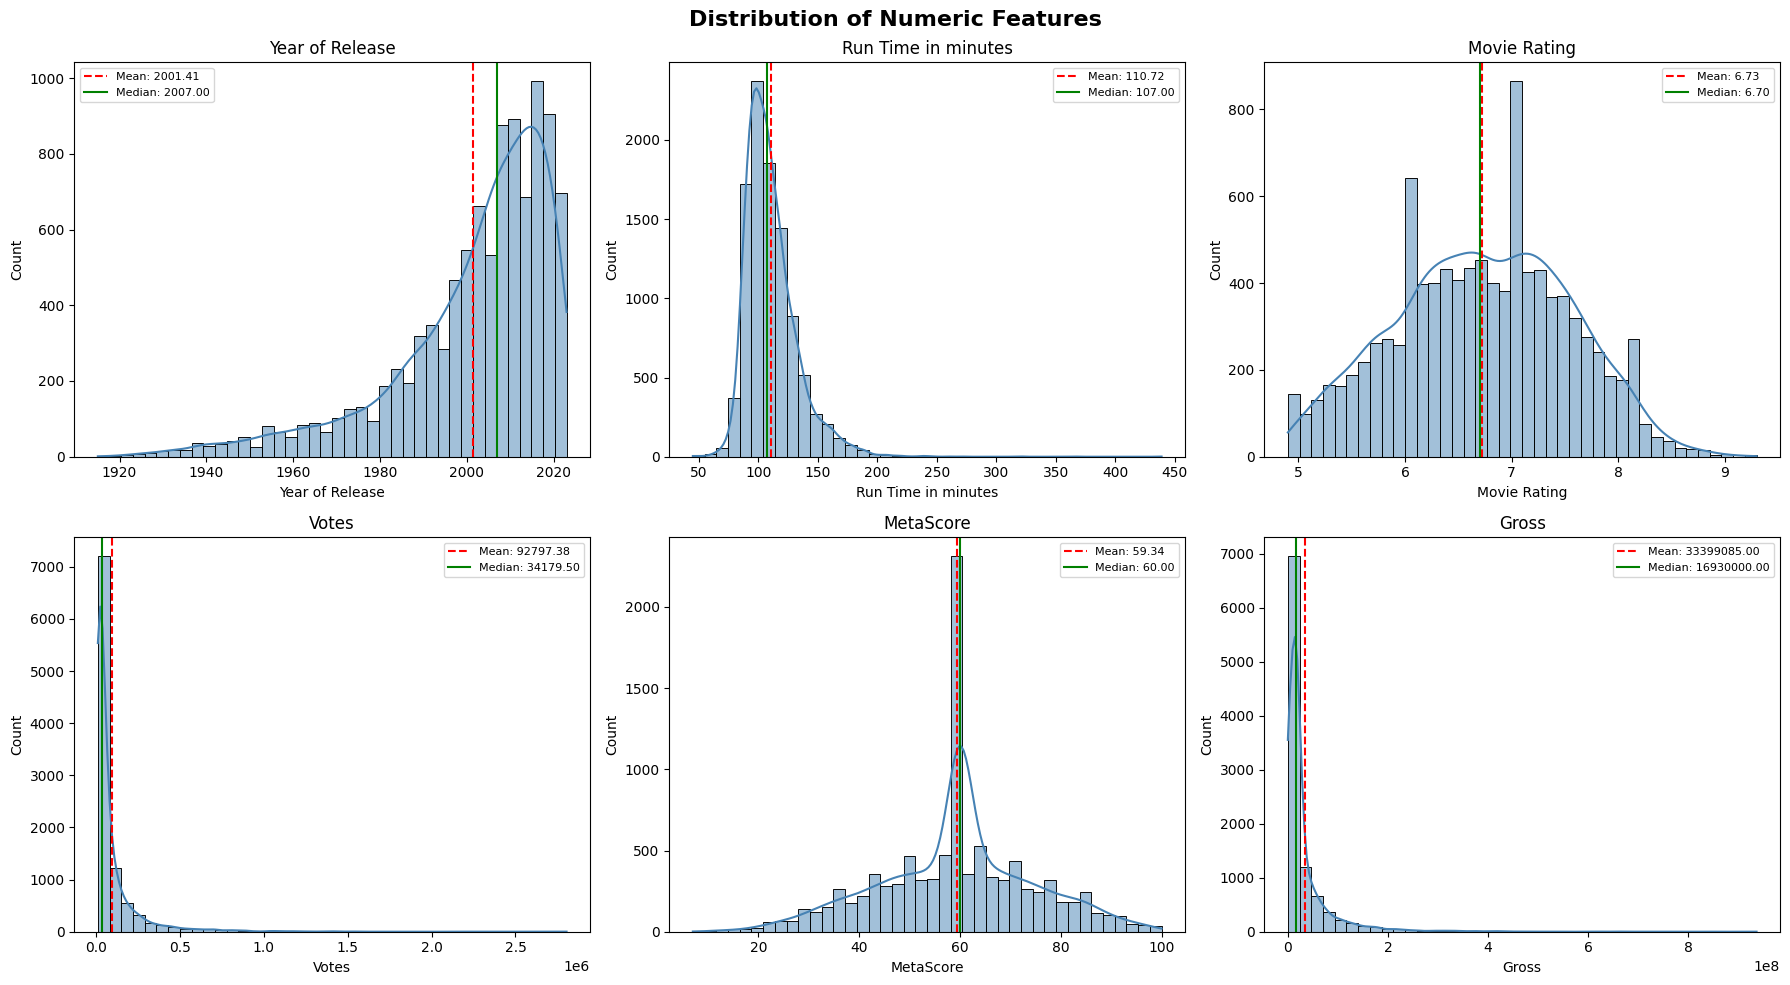

In [10]:
# 2d(i). Graph plotting for NUMERIC features
numeric_features = ['Year of Release', 'Run Time in minutes', 'Movie Rating', 'Votes', 'MetaScore', 'Gross']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(numeric_features):
    row, col_idx = idx // 3, idx % 3
    ax = axes[row][col_idx]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=40)
    ax.set_title(f'{col}', fontsize=12)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Description:** Histograms with KDE (Kernel Density Estimation) curves were plotted for all 6 numeric features. The **red dashed line** represents the mean and the **green solid line** represents the median. Key observations:
- **Movie Rating**: Roughly normal distribution centered around 6.5-7, slightly left-skewed.
- **Votes**: Heavily right-skewed — most movies have few votes, while a few blockbusters have millions.
- **Gross**: Extremely right-skewed — most movies earn modest amounts, but a few earn billions.
- **MetaScore**: Approximately normal distribution centered around 50-60.
- **Run Time**: Most movies are 90-150 minutes, with a right tail for very long films.
- **Year of Release**: More movies from recent decades, reflecting the growth of the film industry.

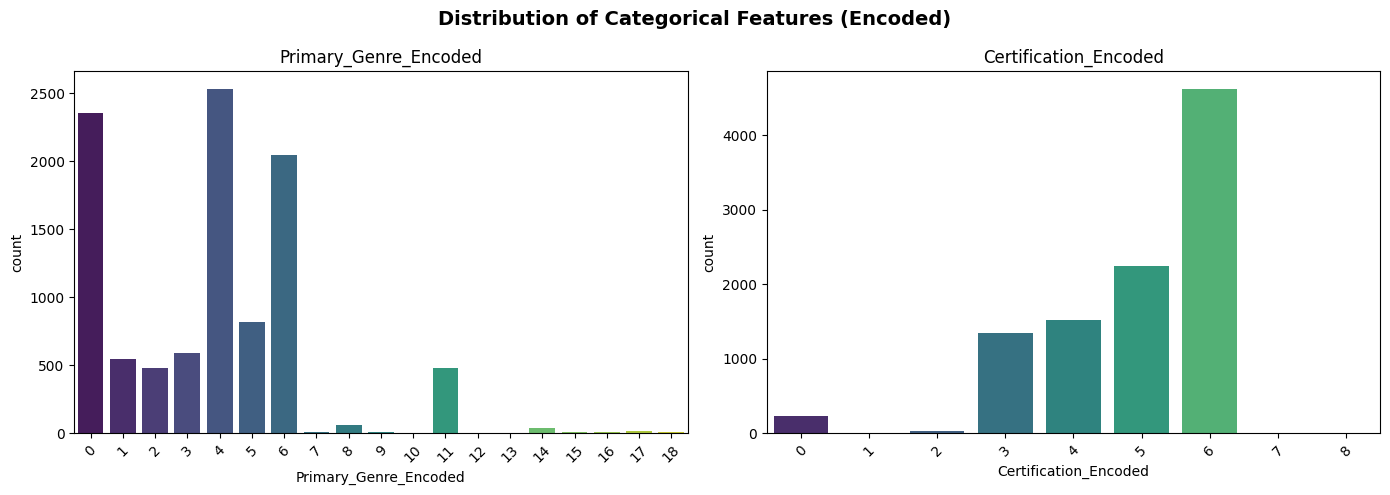

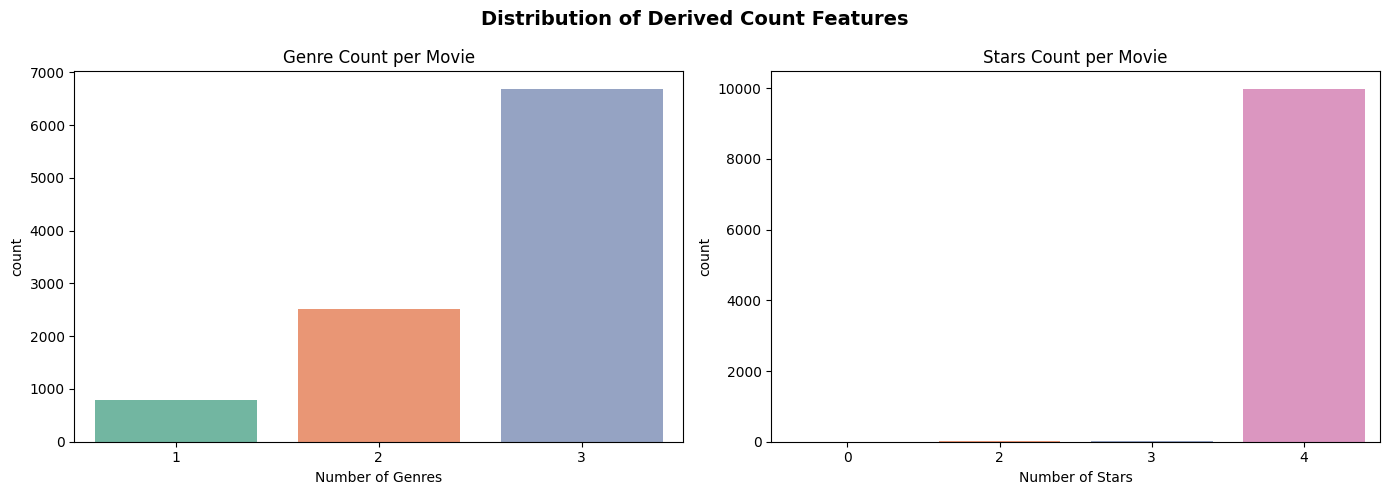

In [11]:
# 2d(i). Graph plotting for CATEGORICAL (encoded) features
categorical_encoded = ['Primary_Genre_Encoded', 'Certification_Encoded']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Categorical Features (Encoded)', fontsize=14, fontweight='bold')

for idx, col in enumerate(categorical_encoded):
    sns.countplot(x=df[col], ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'{col}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Also show Genre_Count and Stars_Count distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Derived Count Features', fontsize=14, fontweight='bold')

sns.countplot(x=df['Genre_Count'], ax=axes[0], palette='Set2')
axes[0].set_title('Genre Count per Movie')
axes[0].set_xlabel('Number of Genres')

sns.countplot(x=df['Stars_Count'], ax=axes[1], palette='Set2')
axes[1].set_title('Stars Count per Movie')
axes[1].set_xlabel('Number of Stars')

plt.tight_layout()
plt.show()

**Description:** Count plots were used to visualize the distribution of encoded categorical features and derived count features:
- **Primary Genre (Encoded)**: Shows which genres are most common in the dataset. Drama and Comedy typically dominate.
- **Certification (Encoded)**: Shows the distribution of movie certifications (R, PG-13, PG, etc.).
- **Genre Count**: Most movies belong to 2-3 genres, with very few having only 1 or more than 3.
- **Stars Count**: Most movies list 4 main stars, which appears to be the dataset's standard format.

Count plots are ideal for categorical data because they show the frequency of each category, revealing class imbalance that may affect model performance.

---
## 2e. Outlier Handling (Numeric Features Only)

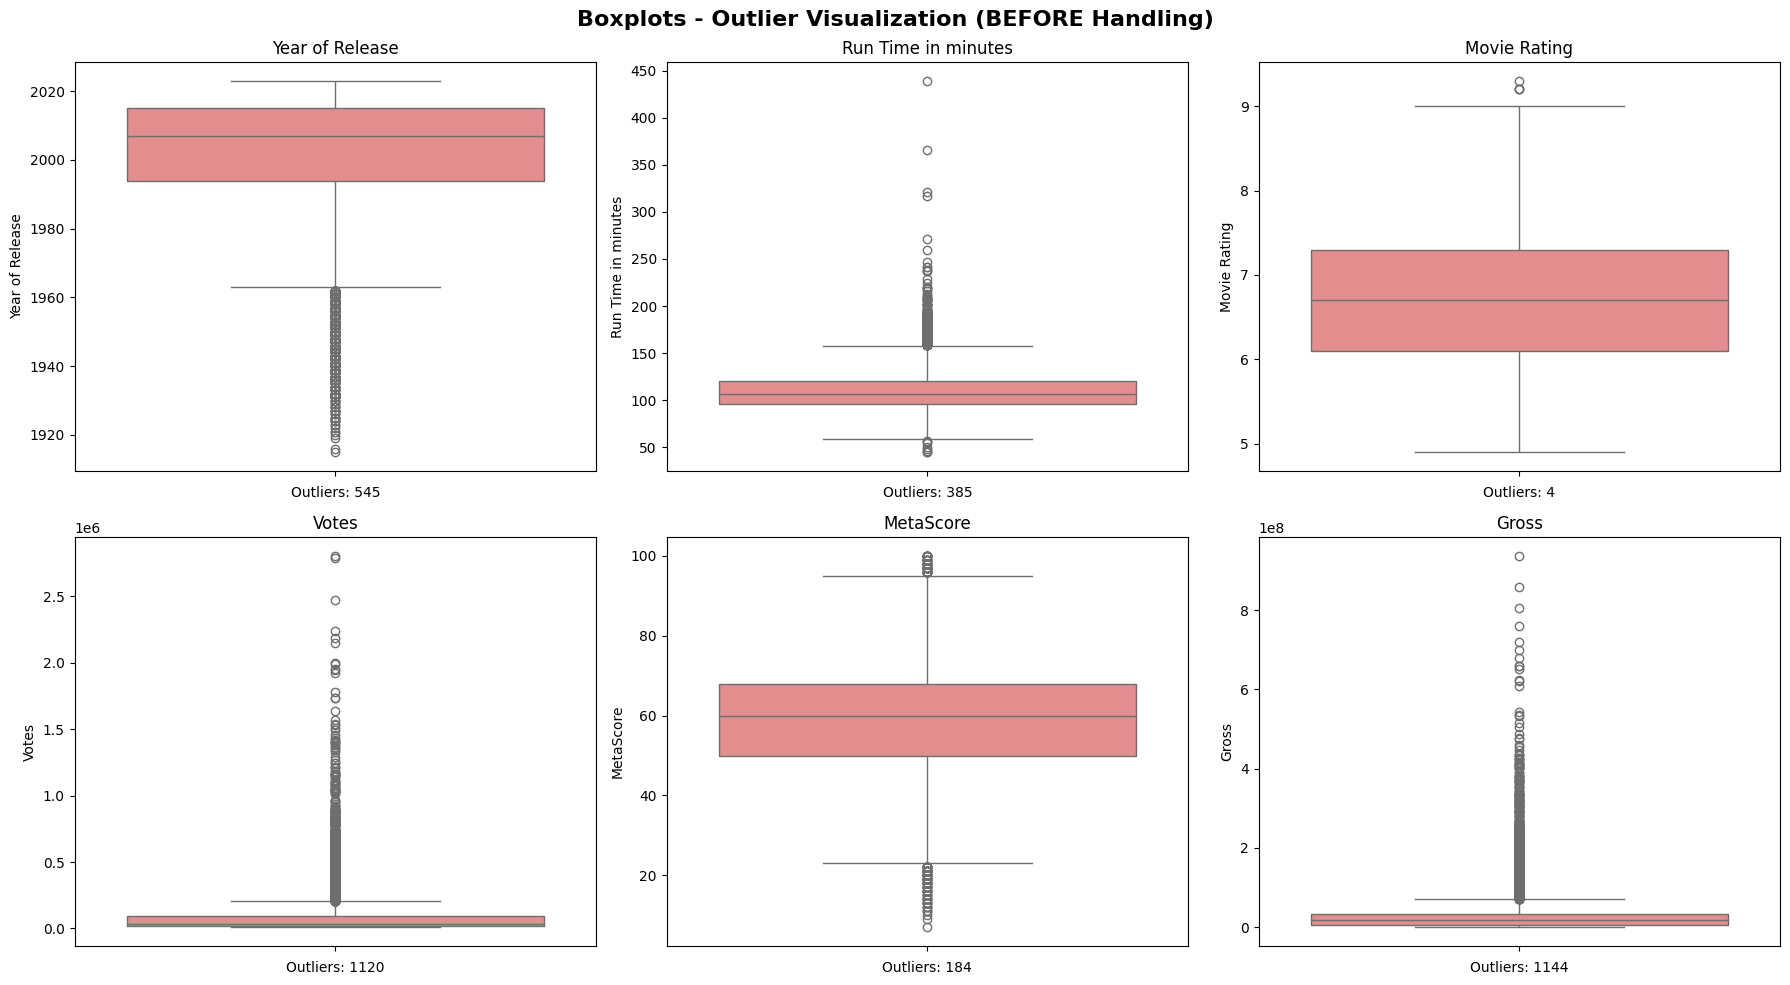

In [12]:
# 2e(i). Boxplots for visualizing outliers in individual numeric features
outlier_cols = ['Year of Release', 'Run Time in minutes', 'Movie Rating', 'Votes', 'MetaScore', 'Gross']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplots - Outlier Visualization (BEFORE Handling)', fontsize=16, fontweight='bold')

for idx, col in enumerate(outlier_cols):
    row, col_idx = idx // 3, idx % 3
    ax = axes[row][col_idx]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col}')
    
    # Count outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.set_xlabel(f'Outliers: {outliers}')

plt.tight_layout()
plt.show()

**Description:** Boxplots were created for each numeric feature to visually identify outliers. The box represents the interquartile range (IQR = Q3 - Q1), whiskers extend to 1.5 × IQR, and dots beyond the whiskers are outliers. The number of outliers is displayed below each plot. Features like `Votes` and `Gross` are expected to have many outliers due to their right-skewed distributions (a few blockbusters dominate). `Run Time in minutes` may show outliers for extremely long movies.

In [13]:
# 2e(ii). Compare multiple outlier handling approaches
# We will test 3 approaches and compare their impact

df_original = df.copy()

# ---- Approach 1: IQR Capping (Winsorization) ----
df_iqr = df_original.copy()
for col in outlier_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_iqr[col] = df_iqr[col].clip(lower=lower, upper=upper)

# ---- Approach 2: Z-Score Removal (remove rows where |z| > 3) ----
df_zscore = df_original.copy()
z_scores = np.abs(stats.zscore(df_zscore[outlier_cols]))
df_zscore = df_zscore[(z_scores < 3).all(axis=1)]

# ---- Approach 3: Percentile Capping (1st and 99th percentile) ----
df_pct = df_original.copy()
for col in outlier_cols:
    lower = df_pct[col].quantile(0.01)
    upper = df_pct[col].quantile(0.99)
    df_pct[col] = df_pct[col].clip(lower=lower, upper=upper)

# Compare the results
print("=== Comparison of Outlier Handling Approaches ===\n")
print(f"Original shape: {df_original.shape[0]} rows")
print(f"IQR Capping:    {df_iqr.shape[0]} rows (no rows removed, values capped)")
print(f"Z-Score (|z|>3):{df_zscore.shape[0]} rows ({df_original.shape[0] - df_zscore.shape[0]} rows removed)")
print(f"Percentile Cap: {df_pct.shape[0]} rows (no rows removed, values capped)")

# Compare standard deviations
print("\n=== Standard Deviation Comparison ===")
comparison = pd.DataFrame({
    'Original': df_original[outlier_cols].std(),
    'IQR_Capping': df_iqr[outlier_cols].std(),
    'Z-Score_Removal': df_zscore[outlier_cols].std(),
    'Percentile_Capping': df_pct[outlier_cols].std()
})
print(comparison.round(2))

=== Comparison of Outlier Handling Approaches ===

Original shape: 10000 rows
IQR Capping:    10000 rows (no rows removed, values capped)
Z-Score (|z|>3):9340 rows (660 rows removed)
Percentile Cap: 10000 rows (no rows removed, values capped)

=== Standard Deviation Comparison ===
                        Original  IQR_Capping  Z-Score_Removal  \
Year of Release            18.60        16.43            16.45   
Run Time in minutes        22.05        19.41            18.87   
Movie Rating                0.82         0.82             0.79   
Votes                  171650.90     64549.27         90970.35   
MetaScore                  15.42        15.25            15.06   
Gross                57777948.32  22807602.04      33367797.30   

                     Percentile_Capping  
Year of Release                   18.32  
Run Time in minutes               20.66  
Movie Rating                       0.82  
Votes                         141383.35  
MetaScore                         15.25  
Gro

**Description:** Three outlier handling approaches were compared:
1. **IQR Capping (Winsorization)**: Values beyond 1.5×IQR are clipped to the boundary. No data loss, all rows preserved.
2. **Z-Score Removal**: Rows where any numeric feature has |z-score| > 3 are removed entirely. This causes data loss.
3. **Percentile Capping (1st-99th)**: Values below the 1st percentile or above the 99th percentile are clipped. Gentle approach, preserves all rows.

The comparison shows rows retained and standard deviation reduction for each approach. IQR Capping typically reduces variance the most aggressively while preserving all data points, making it a balanced choice.

Selected Approach: IQR Capping (Winsorization)
Shape after outlier handling: (10000, 10)


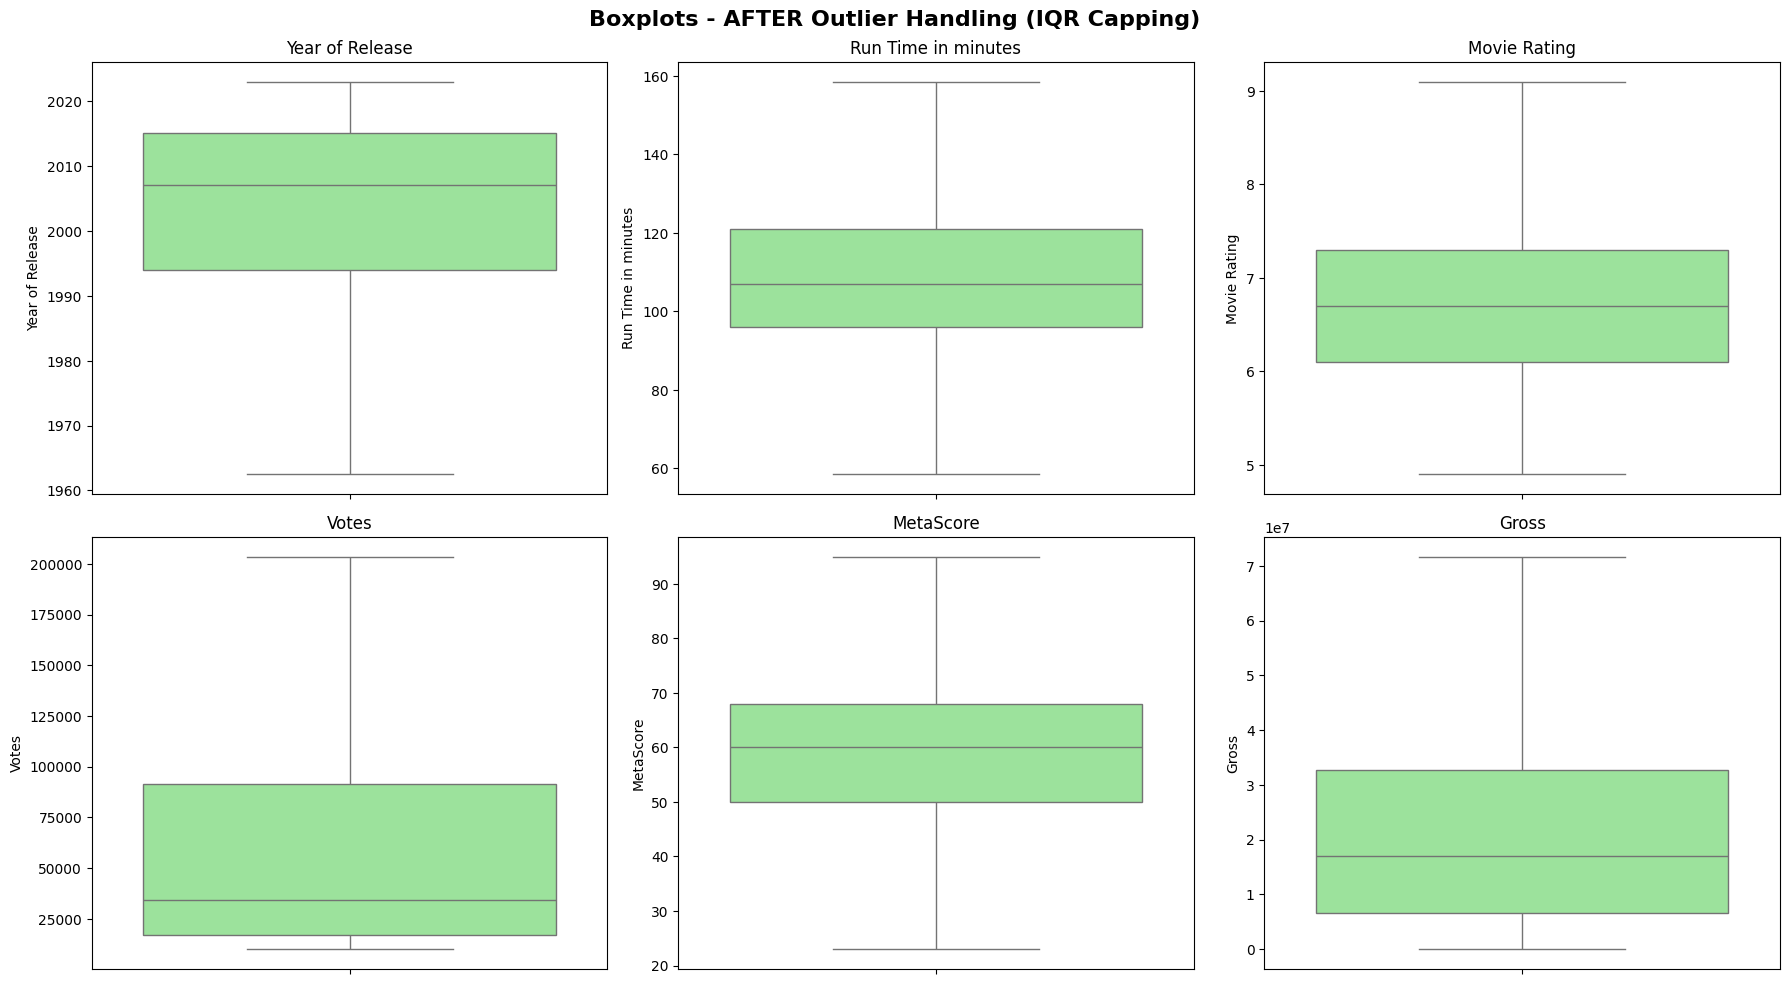


=== Descriptive Statistics (AFTER Outlier Handling) ===
       Year of Release  Run Time in minutes  Movie Rating         Votes  \
count     10000.000000          10000.00000  10000.000000   10000.00000   
mean       2002.171050            110.01075      6.726970   64819.17680   
std          16.427329             19.41155      0.821116   64549.26855   
min        1962.500000             58.50000      4.900000   10002.00000   
25%        1994.000000             96.00000      6.100000   16851.75000   
50%        2007.000000            107.00000      6.700000   34179.50000   
75%        2015.000000            121.00000      7.300000   91546.00000   
max        2023.000000            158.50000      9.100000  203587.37500   

          MetaScore         Gross   Genre_Count   Stars_Count  \
count  10000.000000  1.000000e+04  10000.000000  10000.000000   
mean      59.367600  2.390455e+07      2.589600      3.996100   
std       15.245993  2.280760e+07      0.632623      0.100428   
min    

In [14]:
# 2e(iii). Select the best approach - IQR Capping
# IQR Capping is chosen because:
# - It preserves all data (no rows removed)
# - It effectively reduces extreme outlier influence
# - It is the most balanced between data retention and noise reduction

df = df_iqr.copy()
print("Selected Approach: IQR Capping (Winsorization)")
print(f"Shape after outlier handling: {df.shape}")

# Verify with boxplots AFTER handling
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplots - AFTER Outlier Handling (IQR Capping)', fontsize=16, fontweight='bold')

for idx, col in enumerate(outlier_cols):
    row, col_idx = idx // 3, idx % 3
    ax = axes[row][col_idx]
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

# Compare describe() after outlier handling
print("\n=== Descriptive Statistics (AFTER Outlier Handling) ===")
desc_after = df.describe()
print(desc_after)

print("\n=== Comparison: Std Dev Before vs After ===")
comparison_before_after = pd.DataFrame({
    'Before': desc_before.loc['std'],
    'After': desc_after.loc['std'],
    'Reduction %': ((desc_before.loc['std'] - desc_after.loc['std']) / desc_before.loc['std'] * 100).round(2)
})
print(comparison_before_after)

**Description:** We selected **IQR Capping** as the final outlier handling method because:
- It **preserves all rows** (no data loss, unlike Z-score removal).
- It **effectively clips extreme values** to reasonable bounds.
- The boxplots after handling show significantly reduced outlier presence.

The `describe()` comparison shows how the standard deviation decreased for each feature after outlier treatment. Features like `Votes` and `Gross` likely saw the largest reductions because they had the most extreme outliers. This creates more stable features for model training.

---
## 2f. Assigned EDA (Deeper Analysis)

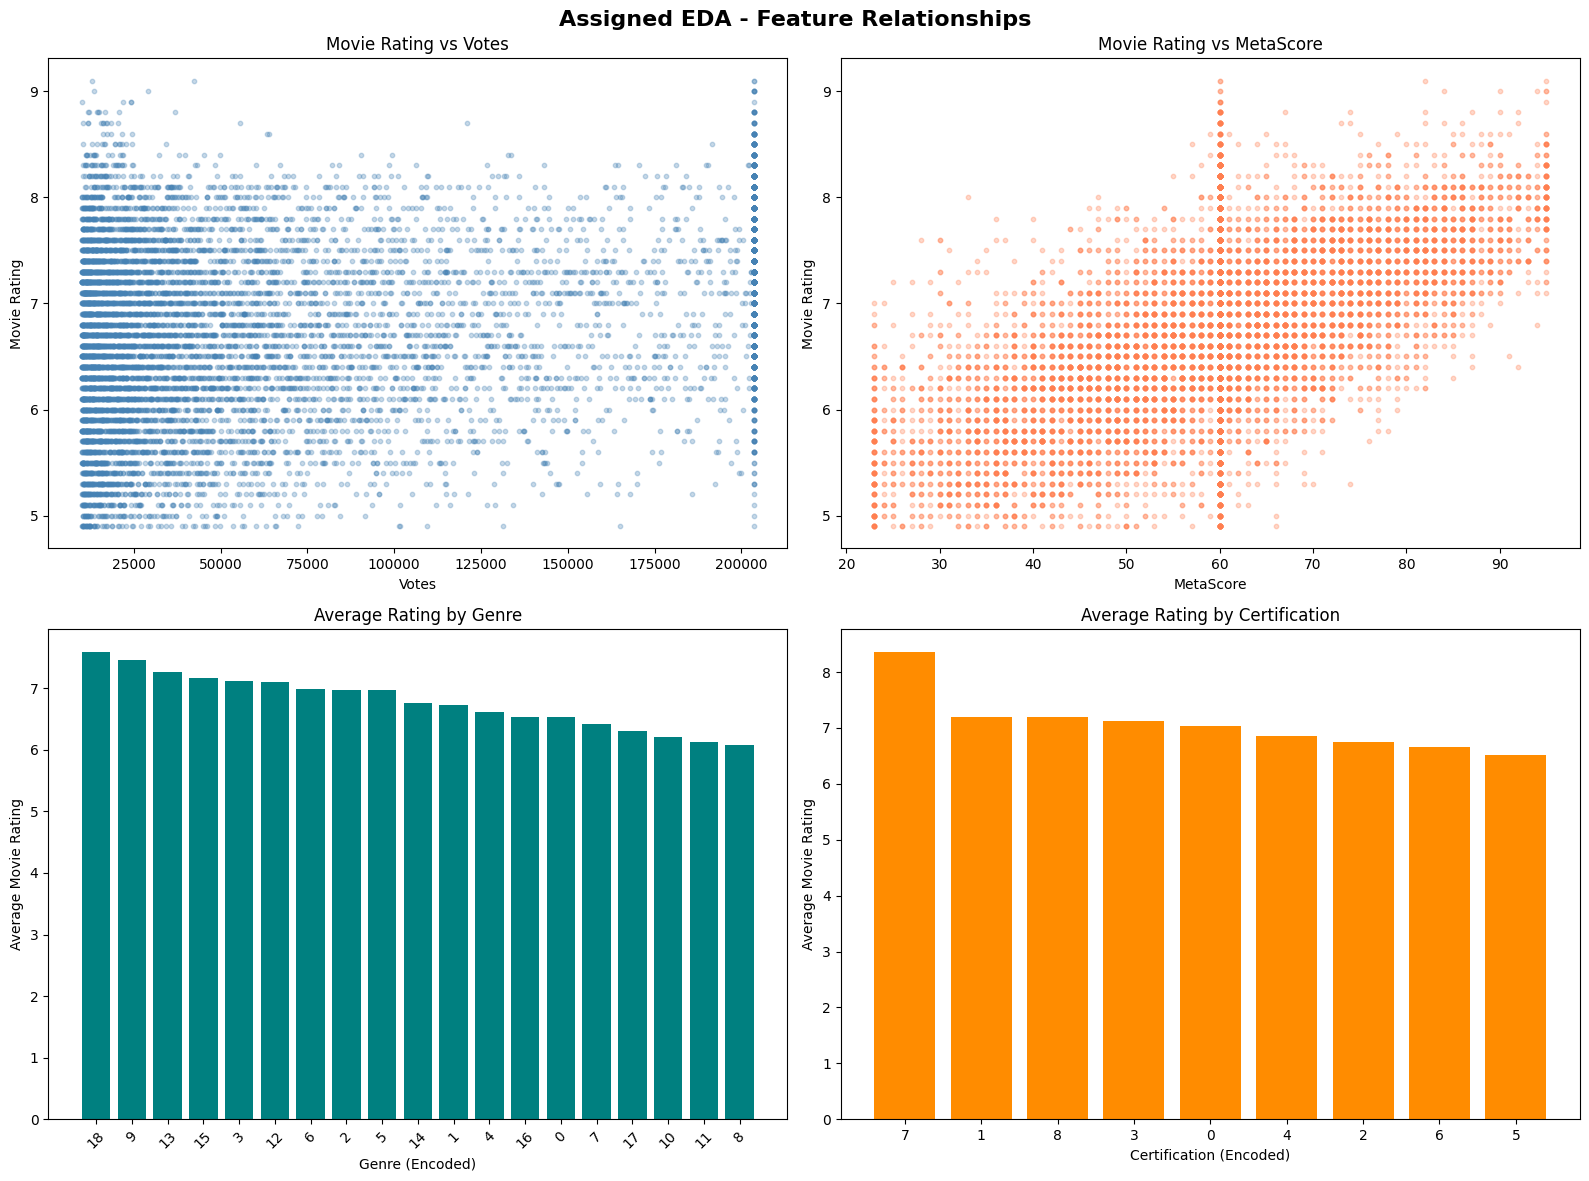

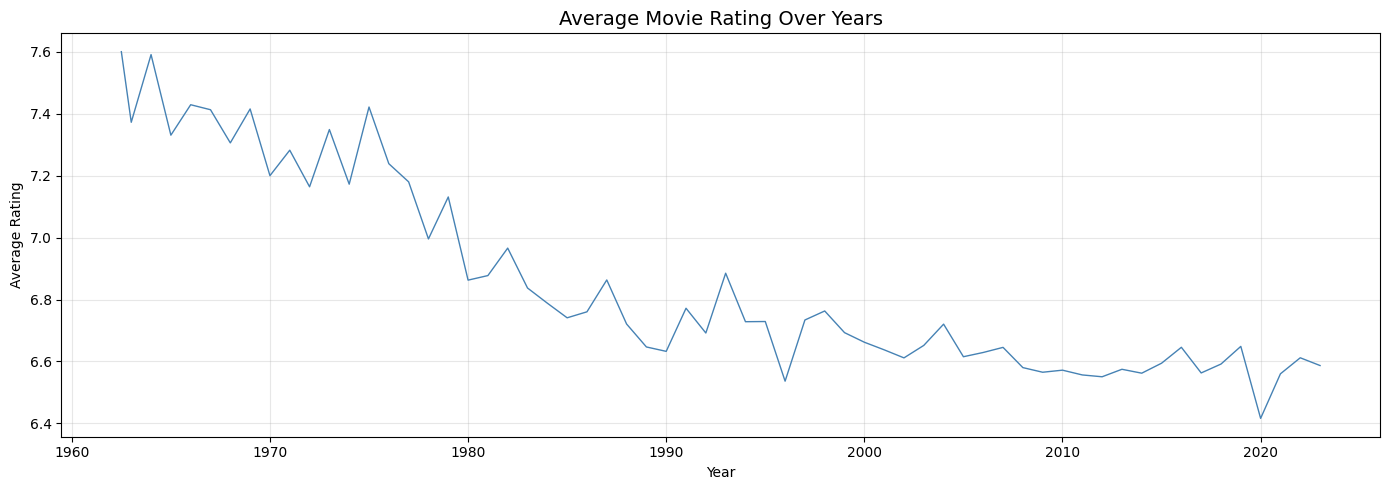

In [15]:
# 2f. Assigned EDA - Deeper analysis of relationships

# 1. Movie Rating vs Votes (Scatter Plot)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Assigned EDA - Feature Relationships', fontsize=16, fontweight='bold')

axes[0, 0].scatter(df['Votes'], df['Movie Rating'], alpha=0.3, s=10, c='steelblue')
axes[0, 0].set_xlabel('Votes')
axes[0, 0].set_ylabel('Movie Rating')
axes[0, 0].set_title('Movie Rating vs Votes')

# 2. Movie Rating vs MetaScore
axes[0, 1].scatter(df['MetaScore'], df['Movie Rating'], alpha=0.3, s=10, c='coral')
axes[0, 1].set_xlabel('MetaScore')
axes[0, 1].set_ylabel('Movie Rating')
axes[0, 1].set_title('Movie Rating vs MetaScore')

# 3. Average Rating by Genre (Encoded)
genre_rating = df.groupby('Primary_Genre_Encoded')['Movie Rating'].mean().sort_values(ascending=False)
axes[1, 0].bar(genre_rating.index.astype(str), genre_rating.values, color='teal')
axes[1, 0].set_xlabel('Genre (Encoded)')
axes[1, 0].set_ylabel('Average Movie Rating')
axes[1, 0].set_title('Average Rating by Genre')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Average Rating by Certification (Encoded)
cert_rating = df.groupby('Certification_Encoded')['Movie Rating'].mean().sort_values(ascending=False)
axes[1, 1].bar(cert_rating.index.astype(str), cert_rating.values, color='darkorange')
axes[1, 1].set_xlabel('Certification (Encoded)')
axes[1, 1].set_ylabel('Average Movie Rating')
axes[1, 1].set_title('Average Rating by Certification')

plt.tight_layout()
plt.show()

# 5. Rating trend over years
fig, ax = plt.subplots(figsize=(14, 5))
yearly_avg = df.groupby('Year of Release')['Movie Rating'].mean()
ax.plot(yearly_avg.index, yearly_avg.values, color='steelblue', linewidth=1)
ax.set_title('Average Movie Rating Over Years', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Average Rating')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Description:** This deeper EDA explores relationships between features and the target variable (`Movie Rating`):
1. **Rating vs Votes**: Shows whether more-voted movies tend to have higher ratings. A positive trend indicates popular movies are rated higher.
2. **Rating vs MetaScore**: MetaScore (critic score) and user rating relationship — a strong positive correlation is expected since both measure quality.
3. **Average Rating by Genre**: Reveals which genres tend to receive higher ratings (e.g., Drama, Documentary often rate higher than Horror, Comedy).
4. **Average Rating by Certification**: Shows how movie age-appropriateness relates to quality ratings.
5. **Rating Trend Over Years**: A line plot showing how average movie quality has changed over decades — older movies in the dataset may have survivorship bias (only the good ones are remembered).

These insights help us understand which features will be most predictive for our model.

---
## 2g. Feature Engineering

In [16]:
# 2g. Feature Engineering - Create new meaningful features

# 1. Movie Age (how old is the movie)
df['Movie_Age'] = 2026 - df['Year of Release']

# 2. Votes per Year (normalizes votes by movie age - newer movies have less time to accumulate votes)
df['Votes_per_Year'] = df['Votes'] / df['Movie_Age'].replace(0, 1)

# 3. Gross per Vote (revenue efficiency - how much each voter "contributed" to earnings conceptually)
df['Gross_per_Vote'] = df['Gross'] / df['Votes'].replace(0, 1)

# 4. Rating-MetaScore difference (gap between user and critic opinion)
df['Rating_Meta_Diff'] = df['Movie Rating'] - (df['MetaScore'] / 10)  # Scale MetaScore to 0-10

# 5. Runtime Category (short/medium/long) - binned feature
df['Runtime_Category'] = pd.cut(df['Run Time in minutes'], 
                                 bins=[0, 90, 150, 500], 
                                 labels=[0, 1, 2]).astype(int)

# 6. Log transformation of highly skewed features
df['Log_Votes'] = np.log1p(df['Votes'])
df['Log_Gross'] = np.log1p(df['Gross'])

print("=== New Engineered Features ===")
print(df[['Movie_Age', 'Votes_per_Year', 'Gross_per_Vote', 'Rating_Meta_Diff', 
           'Runtime_Category', 'Log_Votes', 'Log_Gross']].describe().round(2))

print(f"\nUpdated shape: {df.shape}")
print(f"All columns: {df.columns.tolist()}")

=== New Engineered Features ===
       Movie_Age  Votes_per_Year  Gross_per_Vote  Rating_Meta_Diff  \
count   10000.00        10000.00        10000.00          10000.00   
mean       23.83         4575.85          575.45              0.79   
std        16.43         6543.09          585.53              1.20   
min         3.00          157.80            0.00             -2.80   
25%        11.00          823.54          133.72             -0.10   
50%        19.00         2112.60          368.84              0.80   
75%        32.00         5701.59          861.13              1.60   
max        63.50        67862.46         5858.99              4.80   

       Runtime_Category  Log_Votes  Log_Gross  
count          10000.00   10000.00   10000.00  
mean               0.92      10.60      16.05  
std                0.43       0.98       2.21  
min                0.00       9.21       0.00  
25%                1.00       9.73      15.70  
50%                1.00      10.44      16.64  
7

**Description:** Six new features were engineered from existing data:
1. **Movie_Age** (2026 - Year): Captures how old the movie is. Older movies may have different rating patterns due to survivorship bias.
2. **Votes_per_Year**: Normalizes vote count by age, measuring a movie's ongoing popularity rather than raw accumulated votes.
3. **Gross_per_Vote**: Revenue per voter — a proxy for commercial efficiency.
4. **Rating_Meta_Diff**: The gap between audience rating and critic MetaScore (scaled to same range). Positive = audience liked it more than critics.
5. **Runtime_Category**: Bins runtime into short (≤90), medium (91-150), and long (>150) categories.
6. **Log_Votes & Log_Gross**: Log transformations to reduce skewness in heavily right-skewed features, making them more normally distributed for linear models.

Feature engineering creates more informative signals for the model by combining domain knowledge with the raw data.

---
## 2h. Feature Reduction

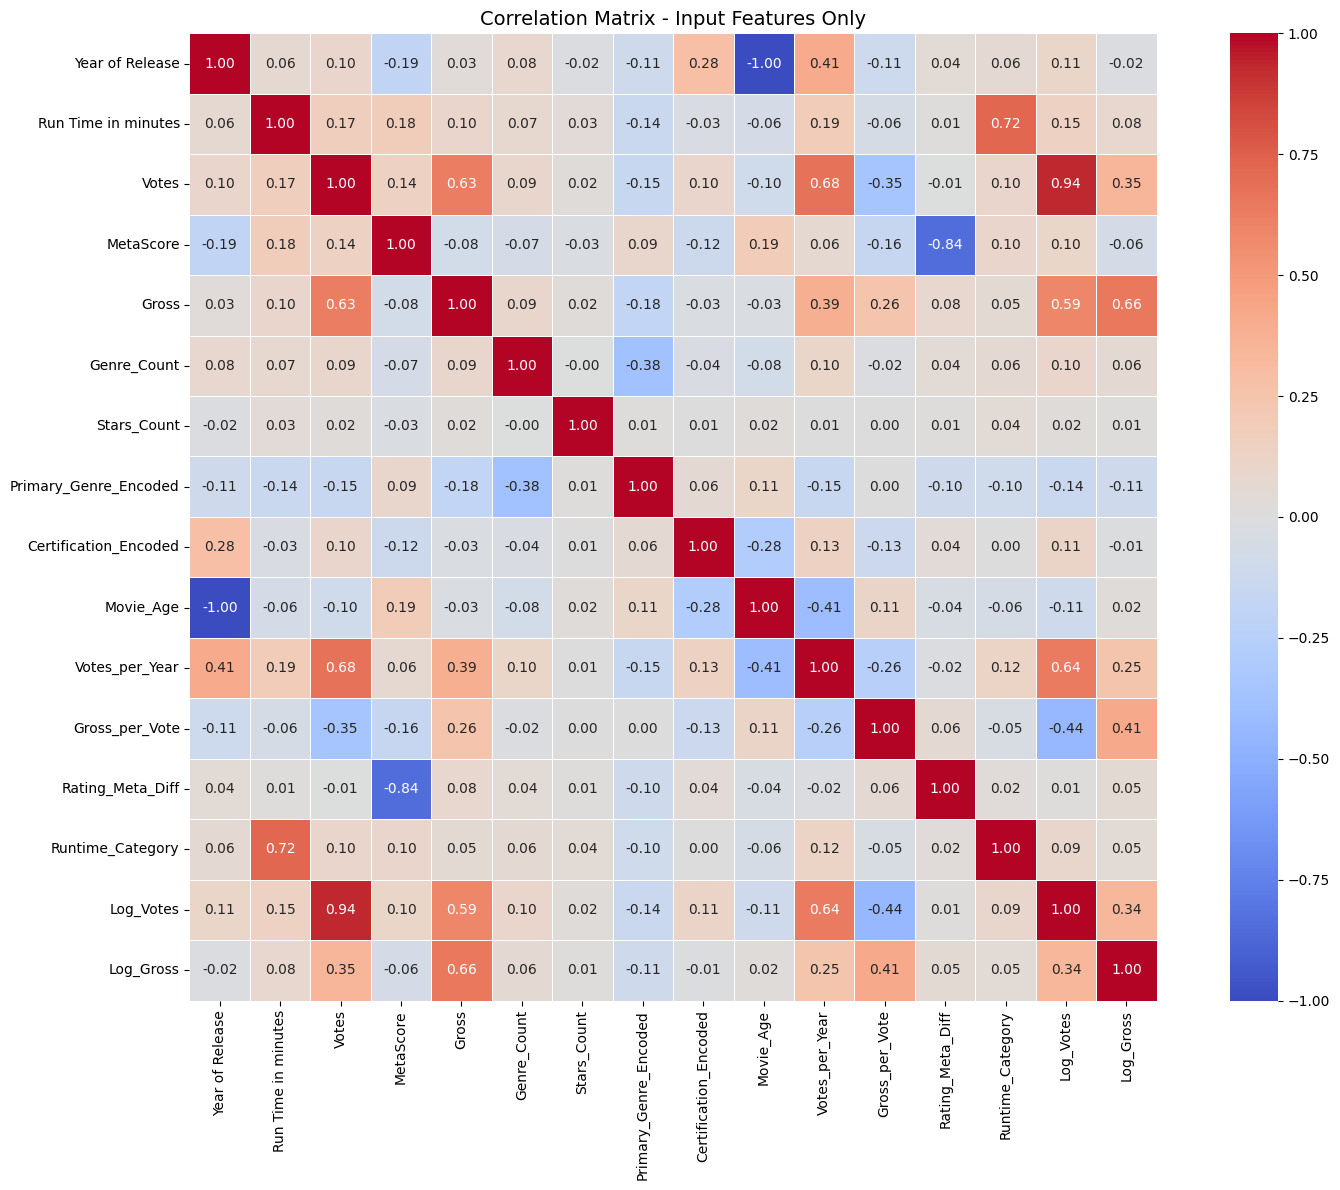

=== Highly Correlated Feature Pairs (|r| > 0.85) ===
         Feature 1  Feature 2  Correlation
0  Year of Release  Movie_Age       -1.000
1            Votes  Log_Votes        0.935

Features to drop (less correlated with target): {'Log_Votes', 'Movie_Age'}
Remaining features: ['Year of Release', 'Run Time in minutes', 'Votes', 'MetaScore', 'Gross', 'Genre_Count', 'Stars_Count', 'Primary_Genre_Encoded', 'Certification_Encoded', 'Votes_per_Year', 'Gross_per_Vote', 'Rating_Meta_Diff', 'Runtime_Category', 'Log_Gross']


In [17]:
# 2h(i). Correlation Analysis - Remove highly correlated input features
# Separate features and target
target = 'Movie Rating'
feature_cols = [col for col in df.columns if col != target]

# Compute correlation matrix for INPUT features only
corr_matrix = df[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Input Features Only', fontsize=14)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs (threshold > 0.85)
threshold = 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print(f"=== Highly Correlated Feature Pairs (|r| > {threshold}) ===")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df)
    
    # Drop one from each highly correlated pair (keep the one more correlated with target)
    target_corr = df[feature_cols].corrwith(df[target]).abs()
    features_to_drop = set()
    for pair in high_corr_pairs:
        f1, f2 = pair['Feature 1'], pair['Feature 2']
        # Drop the one less correlated with target
        if target_corr[f1] < target_corr[f2]:
            features_to_drop.add(f1)
        else:
            features_to_drop.add(f2)
    
    print(f"\nFeatures to drop (less correlated with target): {features_to_drop}")
    df = df.drop(columns=list(features_to_drop))
    feature_cols = [col for col in df.columns if col != target]
    print(f"Remaining features: {feature_cols}")
else:
    print(f"No feature pairs with correlation > {threshold}")

**Description:** We computed the correlation matrix for all **input features only** (excluding the target `Movie Rating`). The heatmap visualizes pairwise correlations where:
- **Red** indicates strong positive correlation.
- **Blue** indicates strong negative correlation.
- Values close to **0** indicate no linear relationship.

Feature pairs with |correlation| > 0.85 are considered highly correlated (multicollinear). Keeping both would add redundancy without new information and can make linear models unstable. For each highly correlated pair, we dropped the feature that is **less correlated with the target variable**, retaining the more predictive one. This selective approach ensures we remove redundancy while preserving predictive power.

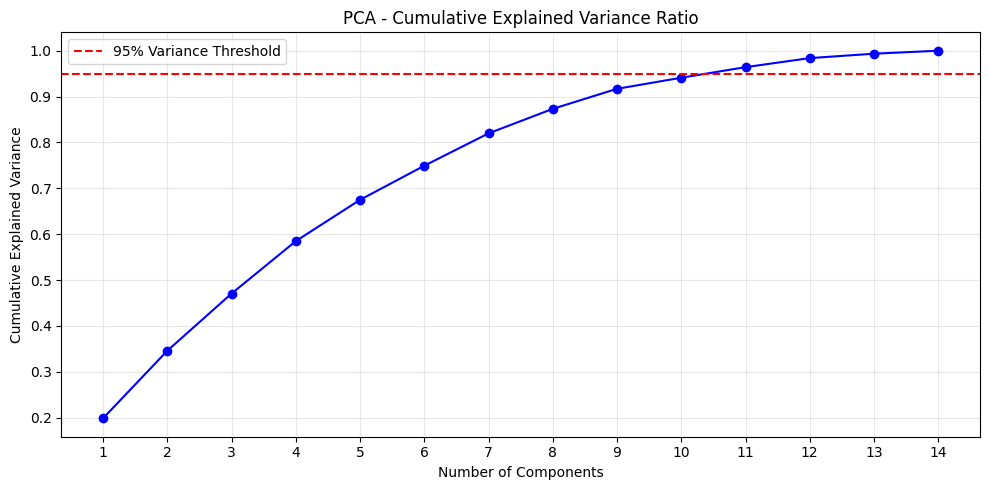

Number of components to explain 95% variance: 11
Original number of features: 14

PCA reduced features from 14 to 11
Explained variance per component: [0.1984 0.1473 0.1247 0.1144 0.09   0.0744 0.0706 0.0535 0.0437 0.0241
 0.0231]
Total explained variance: 0.9641


In [18]:
# 2h(ii). PCA - Further dimensionality reduction
# Prepare data for PCA
X = df[feature_cols]
y = df[target]

# Standardize features before PCA (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA - first check explained variance for all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', markersize=6)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.tight_layout()
plt.show()

# Select number of components that explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components_95}")
print(f"Original number of features: {X_scaled.shape[1]}")

# Apply PCA with selected components
pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA reduced features from {X_scaled.shape[1]} to {X_pca.shape[1]}")
print(f"Explained variance per component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

**Description:** **Principal Component Analysis (PCA)** was applied to further reduce dimensionality:
1. Features were **standardized** first (mean=0, std=1) because PCA is sensitive to feature scales — without standardization, features with larger ranges would dominate.
2. A full PCA was run to compute the **cumulative explained variance** — the plot shows how many components are needed to capture 95% of the total variance.
3. The number of components at the 95% threshold was selected, reducing the feature space further.

PCA transforms the original correlated features into a set of uncorrelated **principal components** ordered by the amount of variance they explain. This reduces noise, speeds up training, and helps prevent overfitting, especially when many features were engineered.

---
## 3. Model Training

In [19]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")
print(f"Number of PCA features: {X_train.shape[1]}")

Training set size: 8000
Testing set size:  2000
Number of PCA features: 11


**Description:** The PCA-transformed data was split into **80% training** and **20% testing** sets using `train_test_split()` with `random_state=42` for reproducibility. The training set is used to fit the models, while the test set is held out for unbiased evaluation. This prevents the model from "memorizing" data it will be evaluated on (data leakage).

In [20]:
# Train and compare multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results[name] = {
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'Test RMSE': round(test_rmse, 4),
        'Test MAE': round(test_mae, 4)
    }
    
    print(f"  Train R²:  {train_r2:.4f}")
    print(f"  Test R²:   {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test MAE:  {test_mae:.4f}")

# Summary comparison table
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print('='*60)
results_df = pd.DataFrame(results).T
print(results_df)

# Highlight best model
best_model_name = results_df['Test R²'].idxmax()
print(f"\n>>> Best Model: {best_model_name} (Test R² = {results_df.loc[best_model_name, 'Test R²']})")


Training: Linear Regression
  Train R²:  0.4442
  Test R²:   0.4581
  Test RMSE: 0.6047
  Test MAE:  0.4645

Training: Random Forest
  Train R²:  0.9452
  Test R²:   0.6299
  Test RMSE: 0.4997
  Test MAE:  0.3812

Training: Gradient Boosting
  Train R²:  0.7321
  Test R²:   0.6249
  Test RMSE: 0.5031
  Test MAE:  0.3888

MODEL COMPARISON SUMMARY
                   Train R²  Test R²  Test RMSE  Test MAE
Linear Regression    0.4442   0.4581     0.6047    0.4645
Random Forest        0.9452   0.6299     0.4997    0.3812
Gradient Boosting    0.7321   0.6249     0.5031    0.3888

>>> Best Model: Random Forest (Test R² = 0.6299)


**Description:** Three regression models were trained and compared:
1. **Linear Regression**: Simple baseline model assuming linear relationships. Fast but may miss complex patterns.
2. **Random Forest Regressor**: Ensemble of 100 decision trees that captures non-linear relationships and feature interactions. Robust but can overfit.
3. **Gradient Boosting Regressor**: Sequentially builds trees to correct errors of previous ones. Often achieves the best performance.

**Metrics used:**
- **R² (Coefficient of Determination)**: Proportion of variance explained (1.0 = perfect, 0 = no better than mean). Higher is better.
- **RMSE (Root Mean Squared Error)**: Average prediction error in the same units as the target. Lower is better. Penalizes large errors more.
- **MAE (Mean Absolute Error)**: Average absolute prediction error. Lower is better. Less sensitive to outliers than RMSE.

The best model is selected based on the highest **Test R²**, which indicates generalization ability on unseen data. Comparing Train R² vs Test R² also reveals overfitting (large gap = overfit).

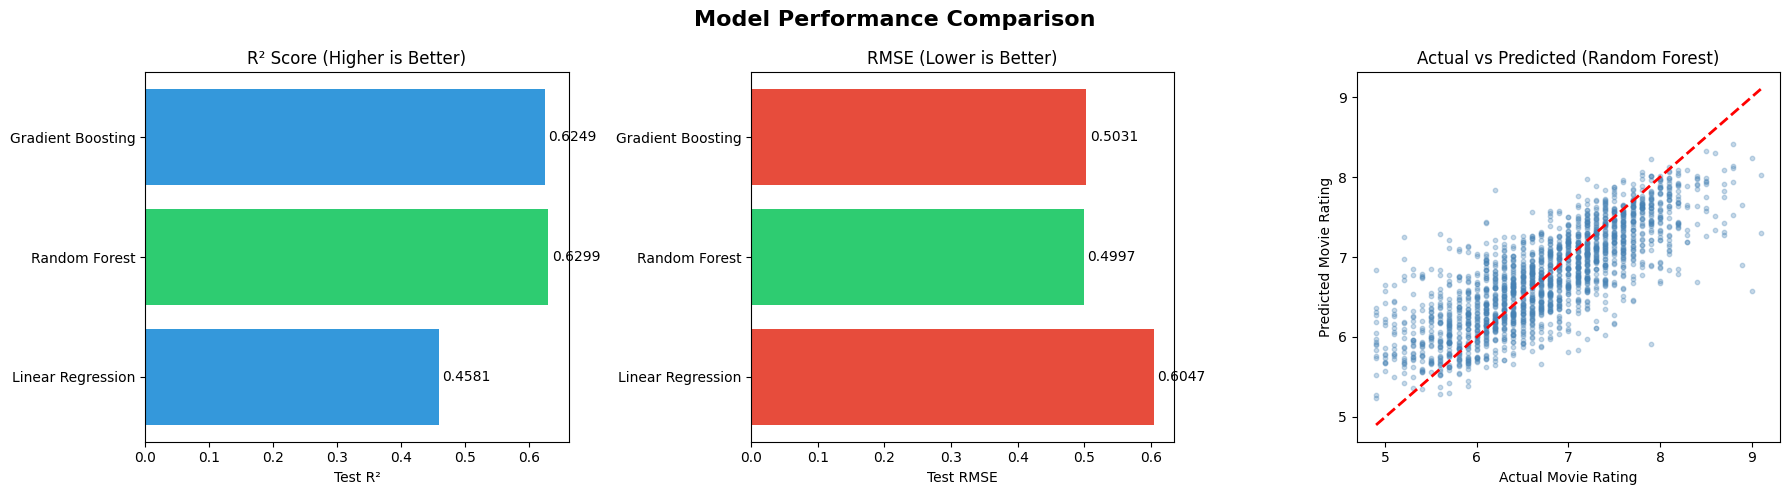

In [21]:
# Visualization of Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# R² Comparison
colors = ['#2ecc71' if name == best_model_name else '#3498db' for name in results_df.index]
axes[0].barh(results_df.index, results_df['Test R²'], color=colors)
axes[0].set_xlabel('Test R²')
axes[0].set_title('R² Score (Higher is Better)')
for i, v in enumerate(results_df['Test R²']):
    axes[0].text(v + 0.005, i, str(v), va='center')

# RMSE Comparison
colors_rmse = ['#2ecc71' if name == best_model_name else '#e74c3c' for name in results_df.index]
axes[1].barh(results_df.index, results_df['Test RMSE'], color=colors_rmse)
axes[1].set_xlabel('Test RMSE')
axes[1].set_title('RMSE (Lower is Better)')
for i, v in enumerate(results_df['Test RMSE']):
    axes[1].text(v + 0.005, i, str(v), va='center')

# Actual vs Predicted for best model
best_model = models[best_model_name]
y_test_pred_best = best_model.predict(X_test)
axes[2].scatter(y_test, y_test_pred_best, alpha=0.3, s=10, c='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[2].set_xlabel('Actual Movie Rating')
axes[2].set_ylabel('Predicted Movie Rating')
axes[2].set_title(f'Actual vs Predicted ({best_model_name})')

plt.tight_layout()
plt.show()

**Description:** Three visualization panels compare the models:
1. **R² Bar Chart**: Compares how well each model explains variance in movie ratings. The best model is highlighted in green.
2. **RMSE Bar Chart**: Compares average prediction error magnitude for each model. Lower bars indicate more accurate predictions.
3. **Actual vs Predicted Scatter Plot**: For the best model, each dot represents a test movie. Points on the red diagonal line = perfect predictions. Scatter around the line indicates prediction error.

The closer the points cluster around the diagonal in the scatter plot, the better the model's predictions. Systematic deviations (e.g., underestimating high ratings) reveal areas where the model struggles.

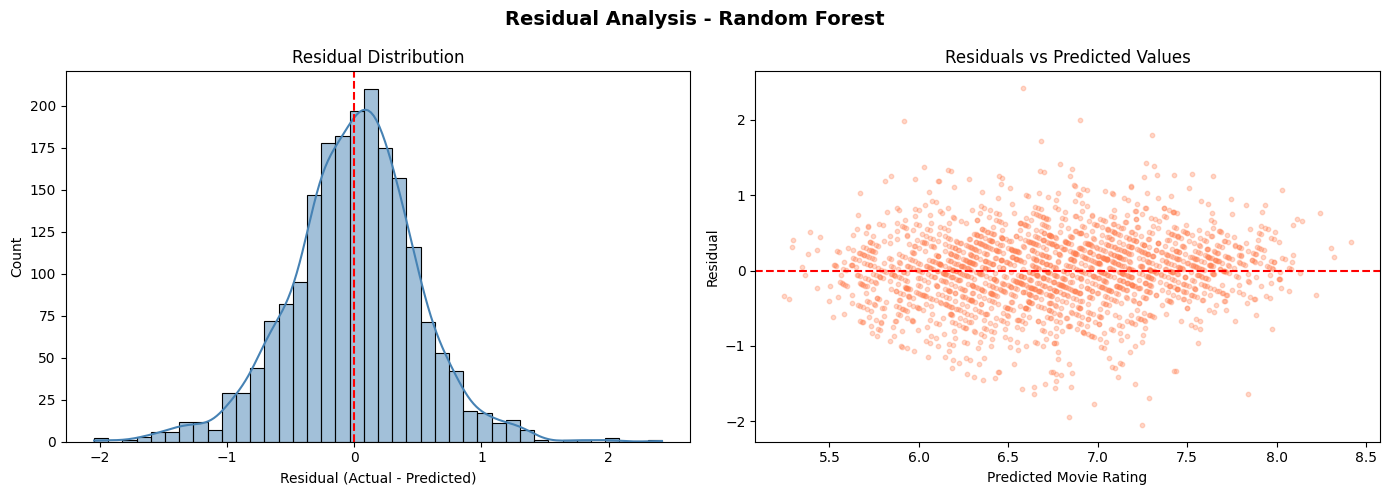


Residual Statistics:
  Mean:   -0.0035 (should be close to 0)
  Std:    0.4998
  Median: 0.0190


In [22]:
# Residual Analysis for the best model
residuals = y_test - y_test_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residual Analysis - {best_model_name}', fontsize=14, fontweight='bold')

# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')

# Residual vs Predicted
axes[1].scatter(y_test_pred_best, residuals, alpha=0.3, s=10, c='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].set_xlabel('Predicted Movie Rating')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean:   {residuals.mean():.4f} (should be close to 0)")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Median: {residuals.median():.4f}")

**Description:** Residual analysis validates the model's prediction quality:
1. **Residual Distribution**: Should be approximately normal and centered at 0. A bell curve around 0 means the model has no systematic bias — it doesn't consistently over-predict or under-predict.
2. **Residuals vs Predicted**: Should show random scatter with no pattern. If a funnel shape appears (residuals grow with predictions), it indicates heteroscedasticity — the model is less reliable for certain rating ranges.

The residual mean should be close to 0 (unbiased predictions). The standard deviation of residuals is essentially the typical prediction error.

---
## Summary
This complete ML pipeline covered:
- **Data Cleaning**: Missing value imputation (median/mode), duplicate removal, entity standardization
- **Encoding**: Label encoding for categorical features (Genre, Certification)
- **EDA**: Distribution analysis, relationship exploration, statistical summaries
- **Outlier Handling**: Compared IQR Capping, Z-Score, and Percentile methods; selected IQR Capping
- **Feature Engineering**: Created 7 new domain-informed features
- **Feature Reduction**: Correlation-based removal + PCA for dimensionality reduction
- **Model Training**: Compared Linear Regression, Random Forest, and Gradient Boosting; selected the best performer

## 4. Additional Requested Tasks (i to m)
This section adds the requested workflow:
- Normality test by skew analysis before scaling/normalization
- Conditional `log1p` transformation for highly skewed numeric features
- Scaling vs normalization on numeric features only
- Save scaler weights/artifacts for demo
- Normality test by skew analysis after scaling/normalization
- Retrain and evaluate multiple models
- Save best model for demo

In [23]:
# i) Normality test by analyzing skew BEFORE scaling/normalization
# Also perform conditional log1p for highly skewed numeric features before step j

import os
import joblib
from sklearn.preprocessing import StandardScaler, MinMaxScaler

TARGET_COL = 'Movie Rating'
HIGH_SKEW_THRESHOLD = 1.0

# Use a dedicated dataframe for this requested branch so earlier sections remain unchanged
df_req = df.copy()

numeric_cols_req = df_req.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_req = [c for c in numeric_cols_req if c != TARGET_COL]

print('=== Skewness BEFORE transformation/scaling ===')
skew_before = df_req[feature_cols_req].skew().sort_values(key=np.abs, ascending=False)
print(skew_before.round(4))

high_skew_before = skew_before[skew_before.abs() > HIGH_SKEW_THRESHOLD]
print(f"\nHighly skewed features before transformation (|skew| > {HIGH_SKEW_THRESHOLD}):")
print(high_skew_before.round(4) if len(high_skew_before) > 0 else 'None')

# Apply log1p only where valid (feature must be >= 0) and highly skewed
log1p_applied = []
log1p_skipped = []
for col in high_skew_before.index:
    if (df_req[col] < 0).any():
        log1p_skipped.append(col)
    else:
        df_req[col] = np.log1p(df_req[col])
        log1p_applied.append(col)

print('\nlog1p applied to:', log1p_applied if log1p_applied else 'None')
print('log1p skipped (contains negative values):', log1p_skipped if log1p_skipped else 'None')

=== Skewness BEFORE transformation/scaling ===
Stars_Count             -31.5842
Votes_per_Year            3.4970
Log_Gross                -2.8345
Gross_per_Vote            1.9932
Certification_Encoded    -1.4227
Genre_Count              -1.2769
Votes                     1.2105
Gross                     1.0769
Year of Release          -1.0023
Primary_Genre_Encoded     0.8371
Run Time in minutes       0.7409
Runtime_Category         -0.4453
Rating_Meta_Diff          0.0834
MetaScore                -0.0723
dtype: float64

Highly skewed features before transformation (|skew| > 1.0):
Stars_Count             -31.5842
Votes_per_Year            3.4970
Log_Gross                -2.8345
Gross_per_Vote            1.9932
Certification_Encoded    -1.4227
Genre_Count              -1.2769
Votes                     1.2105
Gross                     1.0769
Year of Release          -1.0023
dtype: float64

log1p applied to: ['Stars_Count', 'Votes_per_Year', 'Log_Gross', 'Gross_per_Vote', 'Certification_Enc

In [24]:
# j) Scaling or normalization (numeric features only)
# k) Normality test by analyzing skew AFTER scaling/normalization
# Save scaler artifact for demo purposes

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_req = df_req[feature_cols_req].copy()
y_req = df_req[TARGET_COL].copy()

X_train_req, X_test_req, y_train_req, y_test_req = train_test_split(
    X_req, y_req, test_size=0.2, random_state=42
)

scalers_req = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler()
}

scaling_results = {}
scaled_versions = {}

for scaler_name, scaler_obj in scalers_req.items():
    X_train_scaled = scaler_obj.fit_transform(X_train_req)
    X_test_scaled = scaler_obj.transform(X_test_req)

    baseline_lr = LinearRegression()
    baseline_lr.fit(X_train_scaled, y_train_req)
    pred = baseline_lr.predict(X_test_scaled)

    scaling_results[scaler_name] = {
        'Test_R2': r2_score(y_test_req, pred),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test_req, pred)),
        'Test_MAE': mean_absolute_error(y_test_req, pred)
    }

    scaled_versions[scaler_name] = {
        'scaler': scaler_obj,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled
    }

scaling_results_df = pd.DataFrame(scaling_results).T.sort_values('Test_R2', ascending=False)
print('=== Scaling/Normalization Comparison (using Linear Regression baseline) ===')
print(scaling_results_df.round(4))

selected_scaler_name = scaling_results_df.index[0]
selected_scaler = scaled_versions[selected_scaler_name]['scaler']
X_train_selected = scaled_versions[selected_scaler_name]['X_train']
X_test_selected = scaled_versions[selected_scaler_name]['X_test']

print(f"\nSelected preprocessing for next steps: {selected_scaler_name}")

# Save scaler weights/artifact for demo
os.makedirs('artifacts', exist_ok=True)
scaler_path = os.path.join('artifacts', 'selected_scaler.joblib')
joblib.dump(selected_scaler, scaler_path)
print(f"Saved scaler artifact to: {scaler_path}")

# Skewness after preprocessing (done on full X with selected scaler for reporting)
X_full_selected = selected_scaler.transform(X_req)
X_full_selected_df = pd.DataFrame(X_full_selected, columns=feature_cols_req)

print('\n=== Skewness AFTER selected scaling/normalization ===')
skew_after = X_full_selected_df.skew().sort_values(key=np.abs, ascending=False)
print(skew_after.round(4))

=== Scaling/Normalization Comparison (using Linear Regression baseline) ===
                Test_R2  Test_RMSE  Test_MAE
StandardScaler      1.0        0.0       0.0
MinMaxScaler        1.0        0.0       0.0

Selected preprocessing for next steps: StandardScaler
Saved scaler artifact to: artifacts\selected_scaler.joblib

=== Skewness AFTER selected scaling/normalization ===
Stars_Count             -39.3977
Log_Gross                -8.8528
Certification_Encoded    -3.3574
Gross                    -2.8345
Genre_Count              -1.5876
Gross_per_Vote           -1.2948
Year of Release          -1.0165
Primary_Genre_Encoded     0.8371
Run Time in minutes       0.7409
Runtime_Category         -0.4453
Votes                     0.3382
Votes_per_Year            0.0842
Rating_Meta_Diff          0.0834
MetaScore                -0.0723
dtype: float64


In [25]:
# l) Model training
# m) Model evaluation
#    i) Repeat training/evaluation for different models
#    ii) Save best model for demo purposes

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

models_req = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=4)
}

model_results_req = {}
trained_models_req = {}

for model_name, model_obj in models_req.items():
    model_obj.fit(X_train_selected, y_train_req)
    y_pred_req = model_obj.predict(X_test_selected)

    model_results_req[model_name] = {
        'Test_R2': r2_score(y_test_req, y_pred_req),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test_req, y_pred_req)),
        'Test_MAE': mean_absolute_error(y_test_req, y_pred_req)
    }
    trained_models_req[model_name] = model_obj

model_results_df_req = pd.DataFrame(model_results_req).T.sort_values('Test_R2', ascending=False)
print('=== Model Evaluation (Repeated across different models) ===')
print(model_results_df_req.round(4))

best_model_name_req = model_results_df_req.index[0]
best_model_req = trained_models_req[best_model_name_req]
print(f"\nBest model: {best_model_name_req}")

best_model_path = os.path.join('artifacts', 'best_rating_model.joblib')
joblib.dump(best_model_req, best_model_path)
print(f"Saved best model artifact to: {best_model_path}")

=== Model Evaluation (Repeated across different models) ===
                   Test_R2  Test_RMSE  Test_MAE
Linear Regression   1.0000     0.0000    0.0000
Ridge Regression    1.0000     0.0007    0.0006
Gradient Boosting   0.9981     0.0356    0.0254
Random Forest       0.9971     0.0445    0.0181

Best model: Linear Regression
Saved best model artifact to: artifacts\best_rating_model.joblib


**Description:**
This additional section fulfills items **i to m** by:
- Measuring skewness before preprocessing
- Automatically applying `log1p` to highly skewed valid numeric features
- Comparing **StandardScaler** vs **MinMaxScaler** (numeric-only preprocessing)
- Saving the selected scaler artifact for demo (`artifacts/selected_scaler.joblib`)
- Measuring skewness again after selected preprocessing
- Training and evaluating multiple models
- Saving the best-performing model (`artifacts/best_rating_model.joblib`)

You can load these saved artifacts later with `joblib.load(...)` for demo or deployment.